In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
import re as re
from matplotlib import pyplot as plt

In [3]:
con = sqlite3.connect("final_bmarket.db")

In [4]:
df = pd.read_sql_query("SELECT * FROM df_model_table ", con)
df.head()

,client_id,age,campaign_calls,previous_contact_days,occupation_impute_stage,marital_impute_stage,education_impute_stage,subscription_status_encoded,credit_default_enc,housing_loan_enc,...,education_level_basic_9y,education_level_high_school,education_level_illiterate,education_level_professional_course,education_level_university_degree,contact_method_telephone,age_group_26-35,age_group_36-50,age_group_51-65,age_group_65+
0,32885,57,1,NaN,None,None,None,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,3170,55,2,NaN,C,None,A,0,0,1,...,0,0,0,0,1,1,0,0,1,0
2,32207,33,1,NaN,None,None,None,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,9404,36,4,NaN,None,None,None,0,0,0,...,0,1,0,0,0,1,0,1,0,0
4,14021,27,2,NaN,None,None,None,0,0,-1,...,0,1,0,0,0,0,1,0,0,0


In [5]:
X = df.drop(columns=["subscription_status_encoded"])
y = df["subscription_status_encoded"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # only if classification
)


In [7]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train:", y_train.value_counts())

X_train shape: (32950, 37)
X_test shape: (8238, 37)
y_train: subscription_status_encoded
0    29238
1     3712
Name: count, dtype: int64


In [8]:
#count of strings per column
X_train.applymap(lambda x: isinstance(x, str)).sum()

C:\Users\anony\AppData\Local\Temp\ipykernel_3272\2657894860.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train.applymap(lambda x: isinstance(x, str)).sum()


client_id                                 0
age                                       0
campaign_calls                            0
previous_contact_days                     0
occupation_impute_stage                 257
marital_impute_stage                     67
education_impute_stage                 1379
credit_default_enc                        0
housing_loan_enc                          0
personal_loan_enc                         0
previous_contact_flag                     0
contact_intensity                         0
is_higher_edu                             0
loan_burden                               0
occupation_blue_collar                    0
occupation_entrepreneur                   0
occupation_housemaid                      0
occupation_management                     0
occupation_retired                        0
occupation_self_employed                  0
occupation_services                       0
occupation_student                        0
occupation_technician           

In [9]:
#isolating columns with strings
cols_with_strings = (X_train.applymap(lambda x: isinstance(x, str)).sum() > 0)
cols_with_strings = X_train.columns[cols_with_strings]

print(cols_with_strings)

Index(['occupation_impute_stage', 'marital_impute_stage',
       'education_impute_stage'],
      dtype='object')


C:\Users\anony\AppData\Local\Temp\ipykernel_3272\2900707333.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cols_with_strings = (X_train.applymap(lambda x: isinstance(x, str)).sum() > 0)


In [10]:
# dropping columns with string values
X_train = X_train.drop(columns=cols_with_strings)
X_test = X_test.drop(columns=cols_with_strings)

In [11]:
from sklearn.ensemble import RandomForestClassifier
# ?RandomForestClassifier

# Initialize the random forest estimator
# using oob for model evaluation

rf_clf = RandomForestClassifier(oob_score=True,
                                random_state=42,
                                warm_start=True,
                                n_jobs=-1)

oob_list = list()

# Iterate through a range of numbers of trees
for n_trees in [10, 50, 100, 500, 600, 800, 1000, 1100, 1200, 1300, 1400, 1500]:
    # Use this to set the number of trees
    rf_clf.set_params(n_estimators=n_trees)

    # Fit the model
    rf_clf.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - rf_clf.oob_score_

    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob = pd.concat(oob_list, axis=1).T.set_index('n_trees')
rf_oob

C:\Users\anony\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,oob
n_trees,
10.0,0.122094
50.0,0.109803
100.0,0.109014
500.0,0.107800
600.0,0.107618
800.0,0.108437
1000.0,0.108376
1100.0,0.108710
1200.0,0.108649


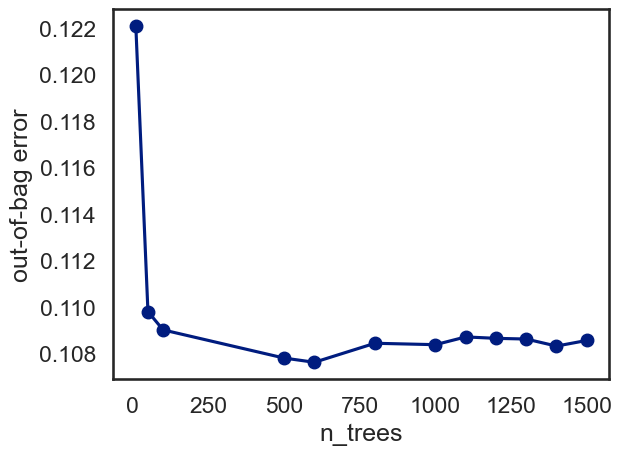

In [12]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = rf_oob.plot(legend=False, marker='o')
ax.set(ylabel='out-of-bag error');

In [13]:
# defime a measure_error function for summarize various errors together
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def measure_error(y_true, y_pred, label):
    return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
                      'precision': precision_score(y_true, y_pred),
                      'recall': recall_score(y_true, y_pred),
                      'f1': f1_score(y_true, y_pred)},
                      name=label)

In [14]:
rf_clf = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_estimators=1100,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

,n_estimators,1100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [15]:
y_test_pred = rf_clf.predict(X_test)

In [16]:
test_error = pd.concat([measure_error(y_test, y_test_pred, 'test')], axis=1)
test_error

,test
accuracy,0.891236
precision,0.535398
recall,0.260776
f1,0.350725


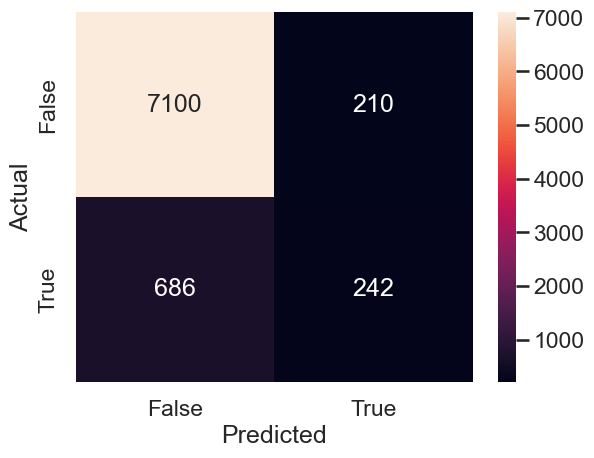

In [17]:
cm = confusion_matrix(y_test, y_test_pred)

sns.set_context('talk')
ax = sns.heatmap(cm, annot=True, fmt='d')
labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels);
ax.set_ylabel('Actual');
ax.set_xlabel('Predicted');